In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
mnist=fetch_openml("mnist_784", version=1, as_frame=False)

In [3]:
mnist.data.shape

(70000, 784)

In [4]:
type(mnist)

sklearn.utils._bunch.Bunch

In [5]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [6]:
x=mnist.data
y=mnist.target

In [7]:
print(x.shape)
print(y.shape)

(70000, 784)
(70000,)


In [8]:
print(type(x), type(y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [9]:
x[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [10]:
y[0]

'5'

In [11]:
y[:10]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4'], dtype=object)

In [12]:
unique, counts=np.unique(y, return_counts=True)

In [13]:
print(unique, counts)

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9'] [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]


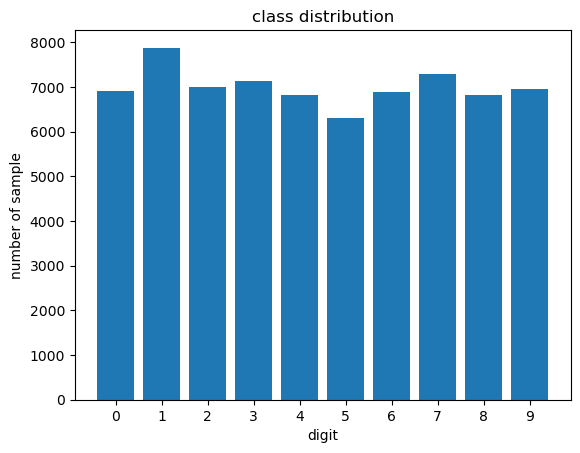

In [14]:
plt.bar(unique, counts)
plt.xlabel("digit")
plt.ylabel("number of sample")
plt.title("class distribution")
plt.show()

In [15]:
sum(counts)

np.int64(70000)

In [16]:
image=x[0].reshape(28, 28)

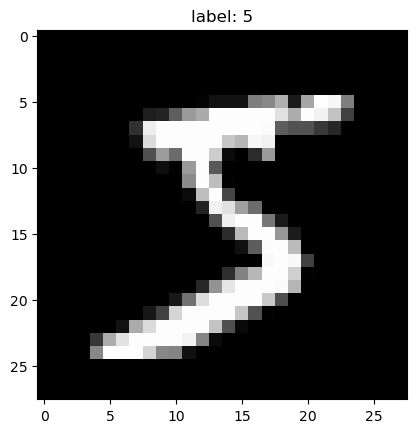

In [17]:
plt.imshow(image, cmap="gray")
plt.title(f"label: {y[0]}")
plt.show()

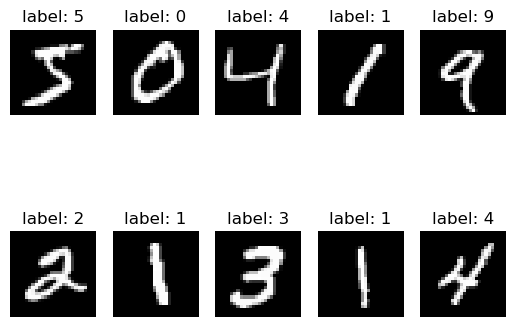

In [18]:
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x[i].reshape(28, 28), cmap="gray")
    plt.title(f"label: {y[i]}")
    plt.axis("off")
    
plt.show()

overview:
- dataset contains 70,000 handwritten digit images
- each image has 784 features(28 x 28 pixels)
- pixel value range is from 0 to 255
- number of classes are 10, classes are from 0 to 9
- the distribution of data is relativly balanced
- each sample contains an image that represents its label


In [19]:
mean_0=x[y=="0"].mean(axis=0)

In [20]:
mean_0.shape

(784,)

In [21]:
mean_image_0=mean_0.reshape(28, 28)

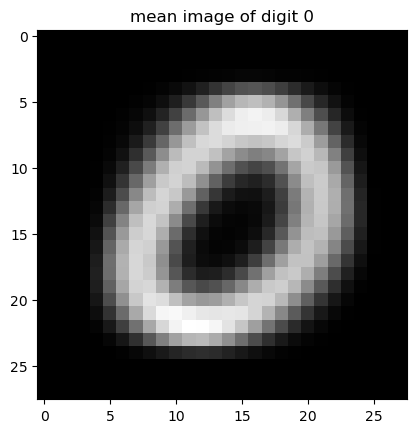

In [22]:
plt.imshow(mean_image_0, cmap="gray")
plt.title("mean image of digit 0")
plt.show()

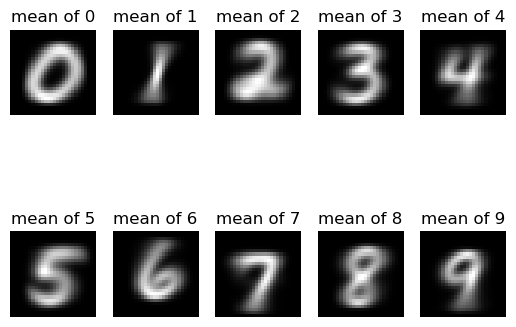

In [23]:
for digit in unique:
    plt.subplot(2, 5, int(digit)+1)
    images=x[y==digit]
    mean_image=images.mean(axis=0).reshape(28, 28)
    plt.imshow(mean_image, cmap="gray")
    plt.title(f"mean of {digit}")
    plt.axis("off")

plt.show()

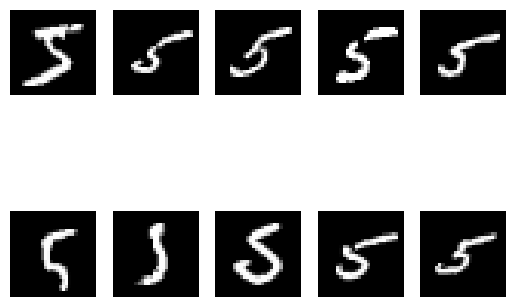

In [24]:
images=x[y=="5"]

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

EDA overview:
- mean image of all digits are recognizable
- examined different samples of the digit to understand handwriting variation

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y)

In [27]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(56000, 784)
(14000, 784)
(56000,)
(14000,)


In [28]:
y_test_unique, y_test_count=np.unique(y_train, return_counts=True)

In [29]:
print(y_test_unique, y_test_count)

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9'] [5522 6302 5592 5713 5459 5050 5501 5834 5460 5567]


In [30]:
x_train=x_train/255
x_test=x_test/255

In [31]:
print(x_train.min())
print(x_train.max())

0.0
1.0


In [32]:
x_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

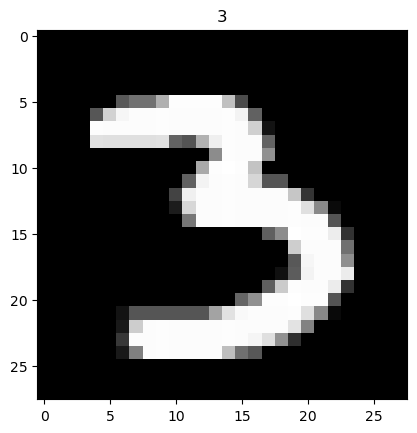

In [33]:
im=x_train[0].reshape(28, 28)
plt.imshow(im, cmap="gray")
plt.title(y_train[0])
plt.show()

data preprocessing overview:
- split the dataset into train and test sets using an 80/20 ratio
- normalized pixel values from the range 0-255 to 0-1
- verified that the normalized images still preserve their

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
model=LogisticRegression(max_iter=1000)

In [36]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [37]:
y_pred=model.predict(x_test)

In [48]:
print(f"actual digits: {y_test[0:9]}")
print(f"predicted digits: {y_pred[0:9]}")

actual digits: ['6' '0' '5' '7' '1' '6' '0' '0' '4']
predicted digits: ['6' '0' '5' '7' '1' '2' '0' '0' '4']


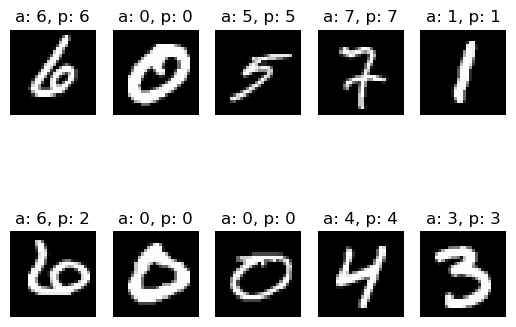

In [51]:
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"a: {y_test[i]}, p: {y_pred[i]}")
    plt.axis("off")
    
plt.show()

In [52]:
from sklearn.metrics import accuracy_score

In [53]:
accuracy_score(y_test, y_pred)

0.9197142857142857

In [56]:
from sklearn.metrics import classification_report

In [62]:
c_report=classification_report(y_test, y_pred, output_dict=True)

In [67]:
pd.DataFrame(c_report)

,0,1,2,3,4,5,6,7,8,9,accuracy,macro avg,weighted avg
precision,0.963309,0.949907,0.914661,0.895299,0.931768,0.87886,0.948551,0.924273,0.899848,0.881979,0.919714,0.918846,0.919527
recall,0.969587,0.975238,0.896996,0.880252,0.930403,0.87886,0.952000,0.936943,0.868864,0.897196,0.919714,0.918634,0.919714
f1-score,0.966438,0.962406,0.905742,0.887712,0.931085,0.87886,0.950272,0.930565,0.884085,0.889522,0.919714,0.918669,0.919548
support,1381.000000,1575.000000,1398.000000,1428.000000,1365.000000,1263.00000,1375.000000,1459.000000,1365.000000,1391.000000,0.919714,14000.000000,14000.000000


In [68]:
from sklearn.metrics import confusion_matrix

In [69]:
confusion_matrix(y_test, y_pred)

array([[1339,    0,    4,    5,    1,   11,   10,    3,    6,    2],
       [   0, 1536,    8,    6,    1,    6,    2,    4,   11,    1],
       [  10,   10, 1254,   28,   18,    4,   19,   15,   31,    9],
       [   3,   10,   39, 1257,    1,   50,    4,   15,   26,   23],
       [   1,    5,    8,    2, 1270,    1,   10,    6,   10,   52],
       [  12,    8,    7,   52,   13, 1110,   17,    6,   26,   12],
       [  11,    2,   13,    0,    8,   22, 1309,    3,    5,    2],
       [   1,    4,   17,    7,   10,    2,    0, 1367,    5,   46],
       [   7,   30,   16,   31,   12,   47,    9,    7, 1186,   20],
       [   6,   12,    5,   16,   29,   10,    0,   53,   12, 1248]])

training baseline model overall:
- trained a logistic regression model as baseline for digit classification
- the model achieved an accuracy of 91.97% on test set
- the classification report showed good performance overall
- the confusion matrics showed that the model confused 3&5, 4&9 and 7&9